# Prática 2

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import OneHotEncoder

SEED = 42
IGNORE = {"meta", "maximal_torque"}

META_R = {
    "D2V": "src/META-IR_D2V.csv",
    "ECoL": "src/META-IR_ECoL.csv",
    "TabPFN": "src/META-IR_TabPFN.csv",
    "Our-Init": "src/META-IR_Our-Init.csv",
    "Our-Full": "src/META-IR_Our-FullMT1.csv",
    "PyMFE": "src/META-IR_PyMFE.csv",
    "Random": "src/META-IR_Random.csv",
}
REP_NAMES = list(META_R.keys())

BASE_DIR = "meta_ir/base"
F1_PATH = f"{BASE_DIR}/F1_score.csv"
SERA_PATH = f"{BASE_DIR}/SERA.csv"

# Abreviações do meta-target (`model`/`strategy`) -> código usado nas colunas "MODEL.STRATEGY"
# dos arquivos de nível base (ex.: "BG.WC", "ML.NO", "SV.SM")
MODEL_ABBR2 = {"BG": "BG", "DT": "DT", "MLP": "ML", "RF": "RF", "SVM": "SV", "XG": "XG"}
STRATEGY_ABBR2 = {"WC": "WC", "GN": "GN", "SMT": "SM", "RU": "RU", "RO": "RO", "NONE": "NO", "SG": "SG"}


def base_col(model_abbrev: str, strategy_code: str) -> str:
    return f"{MODEL_ABBR2[model_abbrev]}.{STRATEGY_ABBR2[strategy_code.upper()]}"


# Em nível base a recomendação é consultada como um par único. `PAIR_SEP` não pode
# aparecer nos códigos de model/strategy.
PAIR_SEP = "__"


def make_pair(model: pd.Series, strategy: pd.Series) -> pd.Series:
    return model.astype(str) + PAIR_SEP + strategy.astype(str)


def split_pair(pair: str) -> tuple[str, str]:
    model, strategy = pair.split(PAIR_SEP)
    return model, strategy

## Nível Meta

In [7]:
def loo_predict(X: pd.DataFrame, y: pd.Series, seed: int = SEED) -> np.ndarray:
    """LOO-RF: uma predição por instância (treina em N-1, prevê a que sobrou)."""
    preds = np.empty(len(X), dtype=object)
    for i in range(len(X)):
        mask = np.ones(len(X), dtype=bool)
        mask[i] = False
        clf = RandomForestClassifier(n_estimators=100, random_state=seed)
        clf.fit(X.iloc[mask], y.iloc[mask])
        preds[i] = clf.predict(X.iloc[i : i + 1])[0]
    return preds


def ohe_feature(pred: np.ndarray, col_name: str) -> pd.DataFrame:
    """One-hot encode de uma coluna prevista, para uso como meta-feature adicional."""
    enc = OneHotEncoder(sparse_output=False)
    arr = enc.fit_transform(pd.DataFrame({col_name: pred}))
    return pd.DataFrame(arr, columns=enc.get_feature_names_out([col_name]))


def loo_predict_model_first(
    X: pd.DataFrame, y_model: pd.Series, y_strategy: pd.Series, seed: int = SEED
) -> tuple[np.ndarray, np.ndarray]:
    """Model-first: `model` e `strategy` são meta-tasks diferentes, encadeadas.

    1) LOO-RF prevê `model` a partir das meta-features (meta-task independente).
    2) O `model` previsto no passo 1 (sempre fora da amostra) vira meta-feature extra
       (one-hot) e um segundo LOO-RF prevê `strategy` sobre as features estendidas.
    """
    model_pred = loo_predict(X, y_model, seed=seed)
    X_model_first = pd.concat(
        [X.reset_index(drop=True), ohe_feature(model_pred, "model_pred")],
        axis=1,
    )
    strategy_pred = loo_predict(X_model_first, y_strategy, seed=seed)
    return model_pred, strategy_pred


def load_meta_r(path: str) -> pd.DataFrame:
    """Carrega, remove instâncias ignoradas e ordena alfabeticamente por ds_n."""
    m = pd.read_csv(path)
    m["ds_n"] = m["ds_n"].astype(str)
    m = m[~m["ds_n"].isin(IGNORE)].copy()
    m = m.sort_values("ds_n").reset_index(drop=True)
    return m


def features_only(m: pd.DataFrame) -> pd.DataFrame:
    return m.drop(columns=["ds_n", "model", "strategy"]).reset_index(drop=True)


# Ordem alfabética por ds_n (ECoL como referência)
ref = load_meta_r(META_R["ECoL"])
instances = ref["ds_n"].tolist()
model_true = ref["model"].astype(str).reset_index(drop=True)
strategy_true = ref["strategy"].astype(str).reset_index(drop=True)
pair_true = make_pair(model_true, strategy_true)

print(f"Instâncias (nível meta): {len(instances)}")
print(f"Classes (model): {sorted(model_true.unique())}")
print(f"Classes (strategy): {sorted(strategy_true.unique())}")
print(f"Pares (model, strategy) observados: {pair_true.nunique()} de até "
      f"{len(model_true.unique()) * len(strategy_true.unique())} combinações possíveis")

Instâncias (nível meta): 215
Classes (model): ['BG', 'DT', 'MLP', 'RF', 'SVM', 'XG']
Classes (strategy): ['GN', 'NONE', 'RO', 'RU', 'SG', 'SMT', 'WC']
Pares (model, strategy) observados: 37 de até 42 combinações possíveis


In [8]:
preds_by_rep = {}
meta_metrics = []

for rep, path in META_R.items():
    m = load_meta_r(path)
    assert set(m["ds_n"]) == set(instances), f"Conjunto de instâncias difere em {rep}"
    m = m.set_index("ds_n").loc[instances].reset_index()
    assert m["model"].astype(str).tolist() == model_true.tolist(), f"Rótulos model diferem em {rep}"
    assert m["strategy"].astype(str).tolist() == strategy_true.tolist(), f"Rótulos strategy diferem em {rep}"

    X = features_only(m)
    model_pred, strategy_pred = loo_predict_model_first(X, model_true, strategy_true)
    pair_pred = make_pair(pd.Series(model_pred), pd.Series(strategy_pred)).to_numpy()
    preds_by_rep[rep] = pair_pred

    meta_metrics.append({
        "representacao": rep,
        "acc_model": accuracy_score(model_true, model_pred),
        "f1_macro_model": f1_score(model_true, model_pred, average="macro", zero_division=0),
        "acc_strategy": accuracy_score(strategy_true, strategy_pred),
        "f1_macro_strategy": f1_score(strategy_true, strategy_pred, average="macro", zero_division=0),
        "acc_par": accuracy_score(pair_true, pair_pred),
        "f1_macro_par": f1_score(pair_true, pair_pred, average="macro", zero_division=0),
    })
    last = meta_metrics[-1]
    print(
        f"[{rep}] model-first concluído — "
        f"model: acc={last['acc_model']:.3f} f1_macro={last['f1_macro_model']:.3f} | "
        f"strategy: acc={last['acc_strategy']:.3f} f1_macro={last['f1_macro_strategy']:.3f} | "
        f"par (consulta nível base): acc={last['acc_par']:.3f} f1_macro={last['f1_macro_par']:.3f}"
    )

meta_metrics_df = pd.DataFrame(meta_metrics).sort_values("f1_macro_par", ascending=False).reset_index(drop=True)
meta_metrics_df

KeyboardInterrupt: 

## Nível Base

In [ ]:
f1_df = pd.read_csv(F1_PATH).set_index("index")
sera_df = pd.read_csv(SERA_PATH).set_index("index")

missing = sorted(set(instances) - set(f1_df.index))
print(f"Datasets em nível meta: {len(instances)}")
print(f"Datasets em nível base: {f1_df.shape[0]}")
print(f"Sem correspondência em nível base: {len(missing)}" + (f" -> {missing}" if missing else ""))


Datasets em nível meta: 215
Datasets em nível base: 218
Sem correspondência em nível base: 0


In [ ]:
idx_by_ds = {ds: i for i, ds in enumerate(instances)}

base_rows = []
for ds in instances:
    if ds not in f1_df.index:
        continue
    i = idx_by_ds[ds]
    f1_row = f1_df.loc[ds]
    sera_row = sera_df.loc[ds]

    row = {
        "ds_n": ds,
        "model_real": model_true.iloc[i],
        "strategy_real": strategy_true.iloc[i],
        "par_real": pair_true.iloc[i],
        "f1_oraculo": f1_row.max(),
        "combo_oraculo_f1": f1_row.idxmax(),
        "sera_oraculo": sera_row.min(),
        "combo_oraculo_sera": sera_row.idxmin(),
    }

    for rep in REP_NAMES:
        par_previsto = preds_by_rep[rep][i]
        model_pred, strategy_pred = split_pair(par_previsto)
        col = base_col(model_pred, strategy_pred)

        row[f"par_previsto_{rep}"] = par_previsto
        row[f"f1_{rep}"] = f1_row[col]
        row[f"sera_{rep}"] = sera_row[col]

    base_rows.append(row)

base_per_instance = pd.DataFrame(base_rows)
base_per_instance

,ds_n,model_real,strategy_real,par_real,f1_oraculo,combo_oraculo_f1,sera_oraculo,combo_oraculo_sera,par_previsto_D2V,f1_D2V,...,sera_Our-Init,par_previsto_Our-Full,f1_Our-Full,sera_Our-Full,par_previsto_PyMFE,f1_PyMFE,sera_PyMFE,par_previsto_Random,f1_Random,sera_Random
0,Moneyball,BG,WC,BG__WC,0.924648,BG.WC,22744.737859,BG.WC,DT__GN,0.829196,...,61985.648264,DT__WC,0.914589,32558.649052,XG__WC,0.352935,2.280447e+06,RF__WC,0.910773,29650.260897
1,QSAR-TID-100063,DT,GN,DT__GN,0.556833,DT.GN,4.889429,SV.RO,SVM__NONE,0.210936,...,7.291293,DT__RO,0.543760,6.753495,DT__GN,0.556833,7.204757e+00,DT__WC,0.541299,6.796172
2,QSAR-TID-10012,SVM,SMT,SVM__SMT,0.662856,DT.WC,6.183778,RF.WC,XG__GN,0.477914,...,8.066845,SVM__GN,0.445724,7.577112,XG__GN,0.477914,1.314858e+01,DT__WC,0.662856,8.037471
3,QSAR-TID-100127,DT,WC,DT__WC,0.277356,SV.SM,1.513146,XG.GN,MLP__WC,0.010379,...,74.931759,DT__RO,0.187033,5.201162,XG__GN,0.124119,1.513146e+00,DT__WC,0.140394,4.676172
4,QSAR-TID-100155,DT,GN,DT__GN,0.578525,DT.GN,2.086423,RF.WC,XG__WC,0.370468,...,18.394126,DT__RO,0.381998,4.612098,BG__GN,0.529829,2.734003e+00,DT__WC,0.492898,3.232183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,treasury,RF,RO,RF__RO,0.986347,RF.RO,2.060985,RF.GN,RF__RO,0.986347,...,2.315939,DT__WC,0.976807,4.473721,RF__RO,0.986347,2.315939e+00,DT__GN,0.974953,4.217484
211,triazines,DT,WC,DT__WC,0.659565,DT.WC,0.142028,DT.SM,MLP__WC,0.387117,...,0.206077,DT__WC,0.659565,0.177804,DT__GN,0.434513,1.983278e-01,SVM__WC,0.472549,0.264397
212,veteran,MLP,GN,MLP__GN,0.368623,ML.GN,164333.387384,ML.NO,XG__GN,0.144334,...,256425.777031,XG__WC,0.033253,281079.983458,RF__GN,0.347828,2.073467e+05,DT__GN,0.285494,312987.316529
213,wind,RF,WC,RF__WC,0.856486,RF.WC,2049.329976,RF.WC,SVM__SMT,0.827130,...,8290.003608,RF__NONE,0.787801,2476.397946,RF__WC,0.856486,2.049330e+03,MLP__WC,0.830272,2518.944870


In [ ]:
f1_heatmap = (
    base_per_instance
    .set_index("ds_n")[[f"f1_{rep}" for rep in REP_NAMES]]
    .sort_index()
)
f1_heatmap.columns = REP_NAMES

fig, ax = plt.subplots(figsize=(12, max(18, len(f1_heatmap) * 0.16)))

image = ax.imshow(
    f1_heatmap.to_numpy(),
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=0,
    vmax=1,
)

ax.set_xticks(np.arange(len(REP_NAMES)))
ax.set_xticklabels(REP_NAMES, rotation=45, ha="right")
ax.set_yticks(np.arange(len(f1_heatmap)))
ax.set_yticklabels(f1_heatmap.index, fontsize=6)
ax.set_xlabel("Representação")
ax.set_ylabel("Dataset")
ax.set_title("F1 por dataset e representação")

fig.colorbar(image, ax=ax, label="F1")
plt.tight_layout()
plt.show()

In [ ]:
meta_cols = ["ds_n", "model_real", "strategy_real", "par_real"]
oraculo_cols = ["f1_oraculo", "sera_oraculo"]

abordagem_cols = [
    col
    for rep in REP_NAMES
    for col in (f"par_previsto_{rep}", f"f1_{rep}", f"sera_{rep}")
]

base_per_instance = base_per_instance[
    meta_cols + oraculo_cols + abordagem_cols
]

base_per_instance

,ds_n,model_real,strategy_real,par_real,f1_oraculo,sera_oraculo,par_previsto_D2V,f1_D2V,sera_D2V,par_previsto_ECoL,...,sera_Our-Init,par_previsto_Our-Full,f1_Our-Full,sera_Our-Full,par_previsto_PyMFE,f1_PyMFE,sera_PyMFE,par_previsto_Random,f1_Random,sera_Random
0,Moneyball,BG,WC,BG__WC,0.924648,22744.737859,DT__GN,0.829196,61022.065352,RF__SG,...,61985.648264,DT__WC,0.914589,32558.649052,XG__WC,0.352935,2.280447e+06,RF__WC,0.910773,29650.260897
1,QSAR-TID-100063,DT,GN,DT__GN,0.556833,4.889429,SVM__NONE,0.210936,5.577047,DT__GN,...,7.291293,DT__RO,0.543760,6.753495,DT__GN,0.556833,7.204757e+00,DT__WC,0.541299,6.796172
2,QSAR-TID-10012,SVM,SMT,SVM__SMT,0.662856,6.183778,XG__GN,0.477914,13.148584,DT__GN,...,8.066845,SVM__GN,0.445724,7.577112,XG__GN,0.477914,1.314858e+01,DT__WC,0.662856,8.037471
3,QSAR-TID-100127,DT,WC,DT__WC,0.277356,1.513146,MLP__WC,0.010379,74.931759,XG__GN,...,74.931759,DT__RO,0.187033,5.201162,XG__GN,0.124119,1.513146e+00,DT__WC,0.140394,4.676172
4,QSAR-TID-100155,DT,GN,DT__GN,0.578525,2.086423,XG__WC,0.370468,18.394126,DT__GN,...,18.394126,DT__RO,0.381998,4.612098,BG__GN,0.529829,2.734003e+00,DT__WC,0.492898,3.232183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,treasury,RF,RO,RF__RO,0.986347,2.060985,RF__RO,0.986347,2.315939,RF__RO,...,2.315939,DT__WC,0.976807,4.473721,RF__RO,0.986347,2.315939e+00,DT__GN,0.974953,4.217484
211,triazines,DT,WC,DT__WC,0.659565,0.142028,MLP__WC,0.387117,0.455654,SVM__GN,...,0.206077,DT__WC,0.659565,0.177804,DT__GN,0.434513,1.983278e-01,SVM__WC,0.472549,0.264397
212,veteran,MLP,GN,MLP__GN,0.368623,164333.387384,XG__GN,0.144334,254539.084293,SVM__GN,...,256425.777031,XG__WC,0.033253,281079.983458,RF__GN,0.347828,2.073467e+05,DT__GN,0.285494,312987.316529
213,wind,RF,WC,RF__WC,0.856486,2049.329976,SVM__SMT,0.827130,2526.930887,RF__WC,...,8290.003608,RF__NONE,0.787801,2476.397946,RF__WC,0.856486,2.049330e+03,MLP__WC,0.830272,2518.944870


In [ ]:
f1_cols = meta_cols + ["f1_oraculo"] + [f"f1_{rep}" for rep in REP_NAMES]
sera_cols = meta_cols + ["sera_oraculo"] + [f"sera_{rep}" for rep in REP_NAMES]

print("=== F1 ===")
display(base_per_instance[f1_cols])

print("\n=== SERA ===")
display(base_per_instance[sera_cols])

=== F1 ===


,ds_n,model_real,strategy_real,par_real,f1_oraculo,f1_D2V,f1_ECoL,f1_TabPFN,f1_Our-Init,f1_Our-Full,f1_PyMFE,f1_Random
0,Moneyball,BG,WC,BG__WC,0.924648,0.829196,0.902559,0.884005,0.869889,0.914589,0.352935,0.910773
1,QSAR-TID-100063,DT,GN,DT__GN,0.556833,0.210936,0.556833,0.556833,0.277993,0.543760,0.556833,0.541299
2,QSAR-TID-10012,SVM,SMT,SVM__SMT,0.662856,0.477914,0.574456,0.574456,0.570100,0.445724,0.477914,0.662856
3,QSAR-TID-100127,DT,WC,DT__WC,0.277356,0.010379,0.124119,0.010379,0.010379,0.187033,0.124119,0.140394
4,QSAR-TID-100155,DT,GN,DT__GN,0.578525,0.370468,0.578525,0.578525,0.370468,0.381998,0.529829,0.492898
...,...,...,...,...,...,...,...,...,...,...,...,...
210,treasury,RF,RO,RF__RO,0.986347,0.986347,0.986347,0.986347,0.986347,0.976807,0.986347,0.974953
211,triazines,DT,WC,DT__WC,0.659565,0.387117,0.356441,0.434513,0.051628,0.659565,0.434513,0.472549
212,veteran,MLP,GN,MLP__GN,0.368623,0.144334,0.333510,0.144334,0.283503,0.033253,0.347828,0.285494
213,wind,RF,WC,RF__WC,0.856486,0.827130,0.856486,0.856486,0.785837,0.787801,0.856486,0.830272



=== SERA ===


,ds_n,model_real,strategy_real,par_real,sera_oraculo,sera_D2V,sera_ECoL,sera_TabPFN,sera_Our-Init,sera_Our-Full,sera_PyMFE,sera_Random
0,Moneyball,BG,WC,BG__WC,22744.737859,61022.065352,31793.839122,57751.688175,61985.648264,32558.649052,2.280447e+06,29650.260897
1,QSAR-TID-100063,DT,GN,DT__GN,4.889429,5.577047,7.204757,7.204757,7.291293,6.753495,7.204757e+00,6.796172
2,QSAR-TID-10012,SVM,SMT,SVM__SMT,6.183778,13.148584,8.855855,8.855855,8.066845,7.577112,1.314858e+01,8.037471
3,QSAR-TID-100127,DT,WC,DT__WC,1.513146,74.931759,1.513146,74.931759,74.931759,5.201162,1.513146e+00,4.676172
4,QSAR-TID-100155,DT,GN,DT__GN,2.086423,18.394126,2.879243,2.879243,18.394126,4.612098,2.734003e+00,3.232183
...,...,...,...,...,...,...,...,...,...,...,...,...
210,treasury,RF,RO,RF__RO,2.060985,2.315939,2.315939,2.315939,2.315939,4.473721,2.315939e+00,4.217484
211,triazines,DT,WC,DT__WC,0.142028,0.455654,0.278863,0.198328,0.206077,0.177804,1.983278e-01,0.264397
212,veteran,MLP,GN,MLP__GN,164333.387384,254539.084293,280549.220258,254539.084293,256425.777031,281079.983458,2.073467e+05,312987.316529
213,wind,RF,WC,RF__WC,2049.329976,2526.930887,2049.329976,2049.329976,8290.003608,2476.397946,2.049330e+03,2518.944870


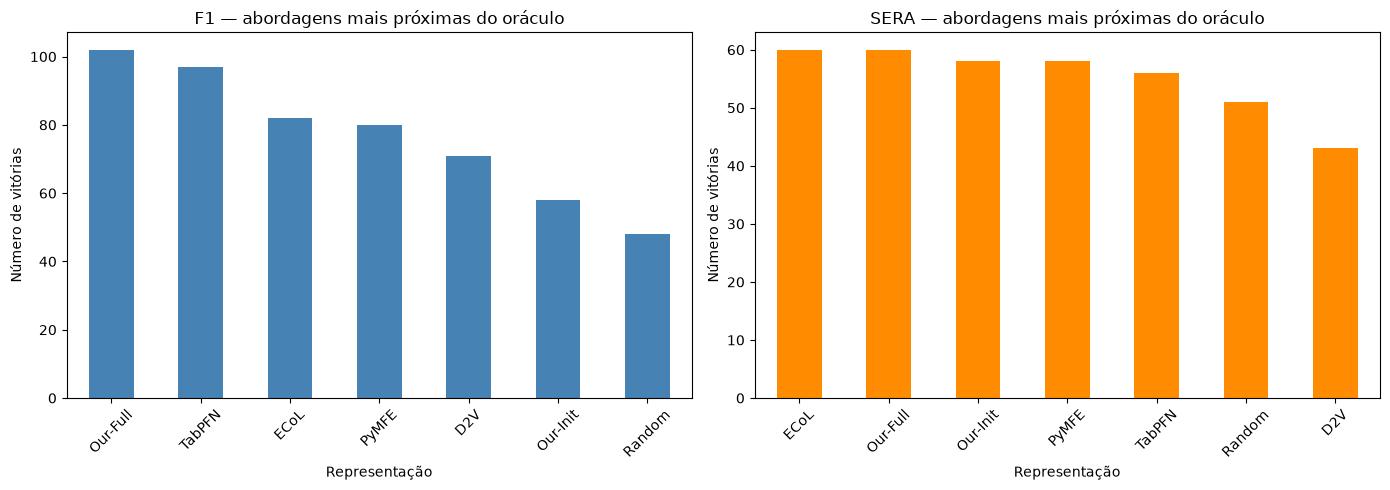

,F1_vitorias,SERA_vitorias
Our-Full,102,60
TabPFN,97,56
ECoL,82,60
PyMFE,80,58
D2V,71,43
Our-Init,58,58
Random,48,51


In [ ]:
import matplotlib.pyplot as plt

def contar_vitorias(metric_prefix: str) -> pd.Series:
    """Conta vitórias, incluindo todas as abordagens empatadas."""
    oracle = base_per_instance[f"{metric_prefix}_oraculo"]
    valores = base_per_instance[[f"{metric_prefix}_{rep}" for rep in REP_NAMES]]
    
    if metric_prefix == "f1":
        distancias = oracle.to_numpy()[:, None] - valores.to_numpy()
    else:  # SERA: quanto menor, melhor
        distancias = valores.to_numpy() - oracle.to_numpy()[:, None]
    
    melhor_distancia = distancias.min(axis=1)
    empates = np.isclose(
        distancias,
        melhor_distancia[:, None],
        rtol=1e-9,
        atol=1e-12,
    )
    
    return pd.Series(empates.sum(axis=0), index=REP_NAMES)


f1_vitorias = contar_vitorias("f1")
sera_vitorias = contar_vitorias("sera")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

f1_vitorias.sort_values(ascending=False).plot(
    kind="bar",
    ax=axes[0],
    color="steelblue",
    title="F1 — abordagens mais próximas do oráculo",
)
axes[0].set_xlabel("Representação")
axes[0].set_ylabel("Número de vitórias")
axes[0].tick_params(axis="x", rotation=45)

sera_vitorias.sort_values(ascending=False).plot(
    kind="bar",
    ax=axes[1],
    color="darkorange",
    title="SERA — abordagens mais próximas do oráculo",
)
axes[1].set_xlabel("Representação")
axes[1].set_ylabel("Número de vitórias")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "F1_vitorias": f1_vitorias,
    "SERA_vitorias": sera_vitorias,
}).sort_values("F1_vitorias", ascending=False))

In [ ]:
summary_rows = []
for rep in REP_NAMES:
    summary_rows.append({
        "representacao": rep,
        "F1_mean": base_per_instance[f"f1_{rep}"].mean(),
        "F1_mean_oraculo": base_per_instance["f1_oraculo"].mean(),
        "SERA_mean": base_per_instance[f"sera_{rep}"].mean(),
        "SERA_mean_oraculo": base_per_instance["sera_oraculo"].mean(),
        "SERA_median": base_per_instance[f"sera_{rep}"].median(),
        "SERA_median_oraculo": base_per_instance["sera_oraculo"].median(),
    })

base_metrics_df = pd.DataFrame(summary_rows).sort_values("F1_mean", ascending=False).reset_index(drop=True)

# Exporta os resultados
base_per_instance.to_csv("src/base_level_per_instancia.csv", index=False)
base_metrics_df.to_csv("src/base_level_metricas.csv", index=False)
print("Salvo: src/base_level_per_instancia.csv")
print("Salvo: src/base_level_metricas.csv")


Salvo: src/base_level_per_instancia.csv
Salvo: src/base_level_metricas.csv


## Análises Comparativas

In [ ]:
print(f"Comparação em nível base: {len(base_per_instance)} datasets "
      f"(de {len(instances)} no nível meta; {len(missing)} sem correspondência em nível base).\n")

print("=== Métricas em Nível Meta (LOO-RF model-first — `model` e `strategy` como meta-tasks diferentes) ===")
display(meta_metrics_df)

print("\n=== Métricas em Nível Base (F1 e SERA reais, par sugerido pelo model-first) ===")
print("Cada linha: valor alcançado pela representação (esquerda) vs. valor oráculo/melhor possível (direita)")
display(base_metrics_df)

Comparação em nível base: 215 datasets (de 215 no nível meta; 0 sem correspondência em nível base).

=== Métricas em Nível Meta (LOO-RF model-first — `model` e `strategy` como meta-tasks diferentes) ===


,representacao,acc_model,f1_macro_model,acc_strategy,f1_macro_strategy,acc_par,f1_macro_par
0,Our-Full,0.679070,0.612044,0.358140,0.243981,0.237209,0.139883
1,PyMFE,0.432558,0.354461,0.334884,0.176906,0.167442,0.080351
2,TabPFN,0.479070,0.378927,0.451163,0.190792,0.195349,0.067361
3,ECoL,0.441860,0.346212,0.372093,0.160284,0.167442,0.066145
4,D2V,0.376744,0.310116,0.288372,0.158460,0.116279,0.055387
5,Our-Init,0.325581,0.269107,0.297674,0.167914,0.097674,0.048506
6,Random,0.288372,0.148132,0.325581,0.099922,0.083721,0.014149



=== Métricas em Nível Base (F1 e SERA reais, par sugerido pelo model-first) ===
Cada linha: valor alcançado pela representação (esquerda) vs. valor oráculo/melhor possível (direita)


,representacao,F1_mean,F1_mean_oraculo,SERA_mean,SERA_mean_oraculo,SERA_median,SERA_median_oraculo
0,TabPFN,0.278428,0.346056,2.612054e+10,1.662420e+10,4.843851,1.884863
1,ECoL,0.274473,0.346056,3.197976e+11,1.662420e+10,4.207019,1.884863
2,PyMFE,0.274453,0.346056,3.872860e+10,1.662420e+10,4.756043,1.884863
3,Our-Full,0.273301,0.346056,2.293610e+10,1.662420e+10,3.902088,1.884863
4,Random,0.249413,0.346056,4.912905e+10,1.662420e+10,6.560225,1.884863
5,D2V,0.247388,0.346056,6.383455e+10,1.662420e+10,5.013513,1.884863
6,Our-Init,0.232376,0.346056,3.851976e+10,1.662420e+10,5.539017,1.884863


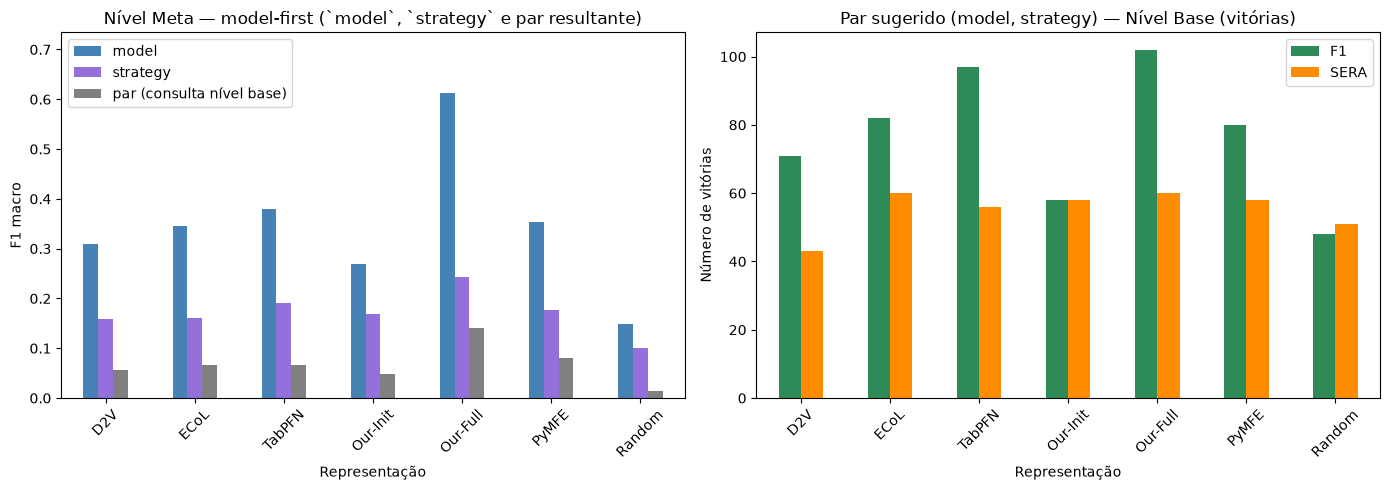

In [ ]:
# Comparação nível meta (F1 macro por meta-task: model, strategy e par resultante)
# vs. nível base (vitórias de F1 e de SERA)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

meta_values = meta_metrics_df.set_index("representacao")[
    ["f1_macro_model", "f1_macro_strategy", "f1_macro_par"]
].reindex(REP_NAMES)

meta_values.plot(
    kind="bar",
    ax=axes[0],
    color=["steelblue", "mediumpurple", "gray"],
    title="Nível Meta — model-first (`model`, `strategy` e par resultante)",
)
axes[0].set_xlabel("Representação")
axes[0].set_ylabel("F1 macro")
axes[0].set_ylim(0, max(meta_values.to_numpy().max() * 1.2, 0.3))
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(["model", "strategy", "par (consulta nível base)"])

pd.DataFrame({
    "F1": f1_vitorias.reindex(REP_NAMES),
    "SERA": sera_vitorias.reindex(REP_NAMES),
}).plot(
    kind="bar",
    ax=axes[1],
    color=["seagreen", "darkorange"],
    title="Par sugerido (model, strategy) — Nível Base (vitórias)",
)
axes[1].set_xlabel("Representação")
axes[1].set_ylabel("Número de vitórias")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(["F1", "SERA"])

plt.tight_layout()
plt.show()

### Teste Estatítico

In [ ]:
import math
from itertools import combinations
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

ALPHA = 0.05


def pairwise_wilcoxon_holm(data: pd.DataFrame, cols: list[str], col_labels: dict[str, str]) -> pd.DataFrame:
    """Matriz de p-valores do teste de Wilcoxon pareado entre representações (mesmos
    datasets, amostras emparelhadas), com correção de Holm-Bonferroni para as
    comparações múltiplas."""
    pairs = list(combinations(cols, 2))
    raw_p = []
    for col_a, col_b in pairs:
        x, y = data[col_a].to_numpy(), data[col_b].to_numpy()
        raw_p.append(1.0 if np.allclose(x, y) else wilcoxon(x, y).pvalue)
    corrected = multipletests(raw_p, method="holm")[1] if raw_p else []

    labels = [col_labels[c] for c in cols]
    p_matrix = pd.DataFrame(np.ones((len(cols), len(cols))), index=labels, columns=labels)
    for (col_a, col_b), p_corr in zip(pairs, corrected):
        la, lb = col_labels[col_a], col_labels[col_b]
        p_matrix.loc[la, lb] = p_corr
        p_matrix.loc[lb, la] = p_corr
    return p_matrix


def plot_performance_diagram(
    data: pd.DataFrame,
    cols: list[str],
    col_labels: dict[str, str],
    lower_better: bool,
    p_matrix: pd.DataFrame,
    alpha: float,
    caption: str,
    ylabel: str,
    width: float = 9.0,
    textspace: float = 1.6,
) -> None:
    """Diagrama no estilo clássico de diferença crítica (Demšar, 2006 / Orange),
    mas com a régua na escala bruta da métrica (média por representação), em vez do
    rank médio. As barras grossas ligam grupos sem diferença estatisticamente
    significativa (Wilcoxon pareado + Holm-Bonferroni)."""
    means = data[cols].mean().rename(index=col_labels)
    names = means.sort_values(ascending=True).index.tolist()
    ssums = means[names].to_numpy()
    k = len(names)

    val_range = ssums.max() - ssums.min()
    margin = val_range * 0.15 if val_range > 0 else 1.0
    lowv, highv = ssums.min() - margin, ssums.max() + margin
    scalewidth = width - 2 * textspace

    def valpos(v):
        return textspace + scalewidth / (highv - lowv) * (v - lowv)

    def fmt(v):
        if abs(v) < 1:
            return f"{v:.3f}"
        if abs(v) < 10:
            return f"{v:.2f}"
        return f"{v:.1f}"

    not_sig = [
        (i, j) for i in range(k) for j in range(i + 1, k)
        if p_matrix.loc[names[i], names[j]] > alpha
    ]

    def is_maximal(pair, pairs):
        i, j = pair
        return not any(
            (i2 <= i and j2 > j) or (i2 < i and j2 >= j)
            for i2, j2 in pairs if (i2, j2) != pair
        )

    clique_lines = [p for p in not_sig if is_maximal(p, not_sig)]

    distanceh = 0.25
    cline = 0.4 + distanceh
    linesblank = 0.4 + max(0, len(clique_lines) - 1) * 0.1
    minnotsignificant = max(0.4, linesblank)

    caption_h = 0.5
    height = cline + ((k + 1) / 2) * 0.2 + minnotsignificant
    total_height = height + caption_h

    fig = plt.figure(figsize=(width, total_height))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)

    wf, hf = 1.0 / width, 1.0 / total_height

    def line(coords, **kwargs):
        ax.plot(
            [c[0] * wf for c in coords],
            [c[1] * hf for c in coords],
            color="black",
            **kwargs,
        )

    def text(x, y, s, **kwargs):
        ax.text(x * wf, y * hf, s, family="serif", **kwargs)

    # Eixo principal (régua na escala bruta da métrica)
    line([(textspace, cline), (width - textspace, cline)], linewidth=0.8)

    bigtick = 0.1
    for a in np.linspace(lowv, highv, 6):
        line([(valpos(a), cline - bigtick / 2), (valpos(a), cline)], linewidth=0.8)
        text(valpos(a), cline - bigtick / 2 - 0.05, fmt(a), ha="center", va="bottom", fontsize=10)

    sentido = "menor = melhor" if lower_better else "maior = melhor"
    text(width / 2, cline - bigtick / 2 - 0.25, f"{ylabel} ({sentido})", ha="center", va="bottom", fontsize=10)

    # Metade com menor valor bruto -> nomes à esquerda
    for i in range(math.ceil(k / 2)):
        chei = cline + minnotsignificant + i * 0.2
        line([(valpos(ssums[i]), cline), (valpos(ssums[i]), chei), (textspace - 0.1, chei)], linewidth=0.8)
        text(textspace - 0.2, chei, names[i], ha="right", va="center", fontsize=11)

    # Metade com maior valor bruto -> nomes à direita
    for i in range(math.ceil(k / 2), k):
        chei = cline + minnotsignificant + (k - i - 1) * 0.2
        line([(valpos(ssums[i]), cline), (valpos(ssums[i]), chei), (width - textspace + 0.1, chei)], linewidth=0.8)
        text(width - textspace + 0.2, chei, names[i], ha="left", va="center", fontsize=11)

    # Barras grossas ligando grupos sem diferença estatisticamente significativa
    bar_y = cline + 0.2
    for l, r in clique_lines:
        line([(valpos(ssums[l]) - 0.03 * scalewidth, bar_y), (valpos(ssums[r]) + 0.03 * scalewidth, bar_y)], linewidth=3)
        bar_y += 0.1

    text(width / 2, height + caption_h * 0.55, caption, ha="center", va="center", fontsize=12)

    plt.show()


def critical_difference_analysis(df: pd.DataFrame, task_name: str) -> pd.DataFrame:
    """Friedman (teste ômnibus sobre ranks) para checar se há alguma diferença entre
    as representações e, em caso positivo, comparações par-a-par por Wilcoxon pareado
    (Holm-Bonferroni) plotadas na escala bruta da métrica (F1/SERA), não em rank."""

    metrics = {
        "F1": ("f1", False),       # maior é melhor
        "SERA": ("sera", True),    # menor é melhor
    }

    results = []

    for metric_name, (prefix, lower_better) in metrics.items():
        cols = [f"{prefix}_{rep}" for rep in REP_NAMES]
        col_labels = dict(zip(cols, REP_NAMES))
        data = df[cols].dropna()

        # Friedman usa os datasets como blocos e as representações como tratamentos
        statistic, p_value = friedmanchisquare(
            *[data[col].to_numpy() for col in cols]
        )

        n = len(data)
        k = len(REP_NAMES)

        p_matrix = pairwise_wilcoxon_holm(data, cols, col_labels)
        n_pares_sig = int((p_matrix.to_numpy() < ALPHA).sum() / 2)

        media_bruta = data[cols].mean().rename(index=col_labels).sort_values(ascending=lower_better)

        results.append({
            "meta_task": task_name,
            "metrica": metric_name,
            "N": n,
            "Friedman_statistic": statistic,
            "Friedman_p_value": p_value,
            "significativo (Friedman)": p_value < ALPHA,
            "pares_significativos (Wilcoxon+Holm)": f"{n_pares_sig}/{k * (k - 1) // 2}",
        })

        print(f"\n{task_name} — {metric_name}")
        print(f"Friedman statistic: {statistic:.4f}")
        print(f"p-value: {p_value:.6g}")
        display(media_bruta.rename(f"{metric_name}_médio").to_frame())
        display(p_matrix.round(4))

        plot_performance_diagram(
            data, cols, col_labels, lower_better, p_matrix, ALPHA,
            f"{task_name} — {metric_name} (Wilcoxon pareado + Holm-Bonferroni, Friedman p = {p_value:.3g})",
            ylabel=metric_name,
        )

    return pd.DataFrame(results)


# Única meta-task avaliada no nível base: o par (model, strategy)
base_friedman_stats = critical_difference_analysis(
    base_per_instance,
    "Predição do par (model, strategy)",
)

display(base_friedman_stats)

NameError: name 'base_per_instance' is not defined

### Análise por nível de desbalanceamento

Categorizei os datasets pelo percentual de casos raros (`%Rare`), calculado com a função de
relevância de Ribeiro (2011).  Os limiares de `%Rare` usados para separar baixo/médio/alto são os mesmos definidos em
Avelino, Cavalcanti & Cruz — *"Imbalanced Regression Pipeline Recommendation"* (2025,
[arXiv:2507.11901](https://arxiv.org/abs/2507.11901)):

- **Baixo**: `%Rare < 8.2`
- **Médio**: `8.2 <= %Rare <= 15.2`
- **Alto**: `%Rare > 15.2`

O objetivo desta análise é verificar se as representações próprias (`Our-Init`, `Our-Full`) se saem melhor ou pior
que as demais (`D2V`, `ECoL`, `TabPFN`, `PyMFE`, `Random`) conforme o grau de desbalanceamento do
dataset.

In [ ]:
DATASETS_DIR = "src/datasets"


def phi_extremes(y: np.ndarray, coef: float = 1.5) -> np.ndarray:
    """Relevância phi (Ribeiro, 2011) - método 'extremes', extr.type 'both'."""
    y = np.asarray(y, dtype=float)
    q1, med, q3 = np.percentile(y, [25, 50, 75])
    iqr = q3 - q1
    adjL = q1 - coef * iqr
    adjH = q3 + coef * iqr

    phi = np.empty_like(y)
    phi[y <= adjL] = 1.0
    phi[y >= adjH] = 1.0

    m1 = (y > adjL) & (y < med)
    t = (y[m1] - adjL) / (med - adjL) if med != adjL else np.zeros(m1.sum())
    phi[m1] = 1.0 + (0.0 - 1.0) * (3 * t**2 - 2 * t**3)

    m2 = (y >= med) & (y < adjH)
    t = (y[m2] - med) / (adjH - med) if adjH != med else np.zeros(m2.sum())
    phi[m2] = 0.0 + (1.0 - 0.0) * (3 * t**2 - 2 * t**3)
    return phi


def pct_rare(ds_n: str, tR: float = 0.8) -> float:
    """Percentual de casos raros (phi(y) > tR) no dataset base `ds_n`."""
    y = pd.read_csv(f"{DATASETS_DIR}/{ds_n}.csv", usecols=["target"])["target"].dropna().to_numpy()
    phi = phi_extremes(y)
    return 100.0 * np.sum(phi > tR) / len(y)


rare_pct = pd.Series({ds: pct_rare(ds) for ds in instances}, name="pct_rare")
base_per_instance["pct_rare"] = base_per_instance["ds_n"].map(rare_pct)
base_per_instance[["ds_n", "pct_rare"]].describe()

NameError: name 'instances' is not defined

In [ ]:
def nivel_desbalanceamento(pct: float) -> str:
    """Categoriza `%Rare` conforme os limiares de Avelino et al. (2025)."""
    if pct < 8.2:
        return "Baixo"
    elif pct <= 15.2:
        return "Médio"
    else:
        return "Alto"


NIVEIS = ["Baixo", "Médio", "Alto"]
base_per_instance["nivel"] = base_per_instance["pct_rare"].apply(nivel_desbalanceamento)

contagem_niveis = base_per_instance["nivel"].value_counts().reindex(NIVEIS)
print("Distribuição dos datasets por nível de desbalanceamento:")
print(contagem_niveis)

Distribuição dos datasets por nível de desbalanceamento (limiares de Avelino et al., 2025):
nivel
Baixo    49
Médio    83
Alto     83
Name: count, dtype: int64


In [ ]:
resumo_por_nivel = []
for nivel in NIVEIS:
    subset = base_per_instance[base_per_instance["nivel"] == nivel]
    for rep in REP_NAMES:
        resumo_por_nivel.append({
            "nivel": nivel,
            "n_datasets": len(subset),
            "representacao": rep,
            "F1_mean": subset[f"f1_{rep}"].mean(),
            "F1_mean_oraculo": subset["f1_oraculo"].mean(),
            "SERA_mean": subset[f"sera_{rep}"].mean(),
            "SERA_mean_oraculo": subset["sera_oraculo"].mean(),
        })

resumo_por_nivel_df = pd.DataFrame(resumo_por_nivel)
resumo_por_nivel_df.sort_values(["nivel", "F1_mean"], ascending=[True, False]).reset_index(drop=True)

,nivel,n_datasets,representacao,F1_mean,F1_mean_oraculo,SERA_mean,SERA_mean_oraculo
0,Alto,83,Our-Full,0.164375,0.208461,2.726018e+06,2.436535e+06
1,Alto,83,ECoL,0.159841,0.208461,7.779842e+06,2.436535e+06
2,Alto,83,TabPFN,0.158759,0.208461,5.858857e+06,2.436535e+06
3,Alto,83,PyMFE,0.158640,0.208461,8.014857e+06,2.436535e+06
4,Alto,83,D2V,0.146030,0.208461,3.098203e+06,2.436535e+06
5,Alto,83,Random,0.145319,0.208461,6.892925e+06,2.436535e+06
6,Alto,83,Our-Init,0.125441,0.208461,7.579455e+06,2.436535e+06
7,Baixo,49,ECoL,0.412899,0.493523,2.915635e+05,2.319088e+05
8,Baixo,49,TabPFN,0.397936,0.493523,2.919031e+05,2.319088e+05
9,Baixo,49,Our-Full,0.391321,0.493523,2.928291e+05,2.319088e+05


In [ ]:
def contar_vitorias_subset(df: pd.DataFrame, metric_prefix: str) -> pd.Series:
    """Mesma lógica de `contar_vitorias`, aplicada a um subconjunto de instâncias."""
    oracle = df[f"{metric_prefix}_oraculo"]
    valores = df[[f"{metric_prefix}_{rep}" for rep in REP_NAMES]]

    if metric_prefix == "f1":
        distancias = oracle.to_numpy()[:, None] - valores.to_numpy()
    else:  # SERA: quanto menor, melhor
        distancias = valores.to_numpy() - oracle.to_numpy()[:, None]

    melhor_distancia = distancias.min(axis=1)
    empates = np.isclose(
        distancias,
        melhor_distancia[:, None],
        rtol=1e-9,
        atol=1e-12,
    )
    return pd.Series(empates.sum(axis=0), index=REP_NAMES)


vitorias_por_nivel = {}
for nivel in NIVEIS:
    subset = base_per_instance[base_per_instance["nivel"] == nivel]
    vitorias_por_nivel[nivel] = pd.DataFrame({
        "F1_vitorias": contar_vitorias_subset(subset, "f1"),
        "SERA_vitorias": contar_vitorias_subset(subset, "sera"),
    })
    print(f"=== {nivel} (n={len(subset)}) ===")
    display(vitorias_por_nivel[nivel].sort_values("F1_vitorias", ascending=False))

=== Baixo (n=49) ===


,F1_vitorias,SERA_vitorias
Our-Full,22,8
ECoL,20,21
PyMFE,18,23
TabPFN,17,19
D2V,12,15
Random,10,10
Our-Init,9,13


=== Médio (n=83) ===


,F1_vitorias,SERA_vitorias
Our-Full,40,31
TabPFN,38,23
PyMFE,34,22
ECoL,28,19
Our-Init,24,20
D2V,23,14
Random,13,15


=== Alto (n=83) ===


,F1_vitorias,SERA_vitorias
TabPFN,42,14
Our-Full,40,21
D2V,36,14
ECoL,34,20
PyMFE,28,13
Our-Init,25,25
Random,25,26


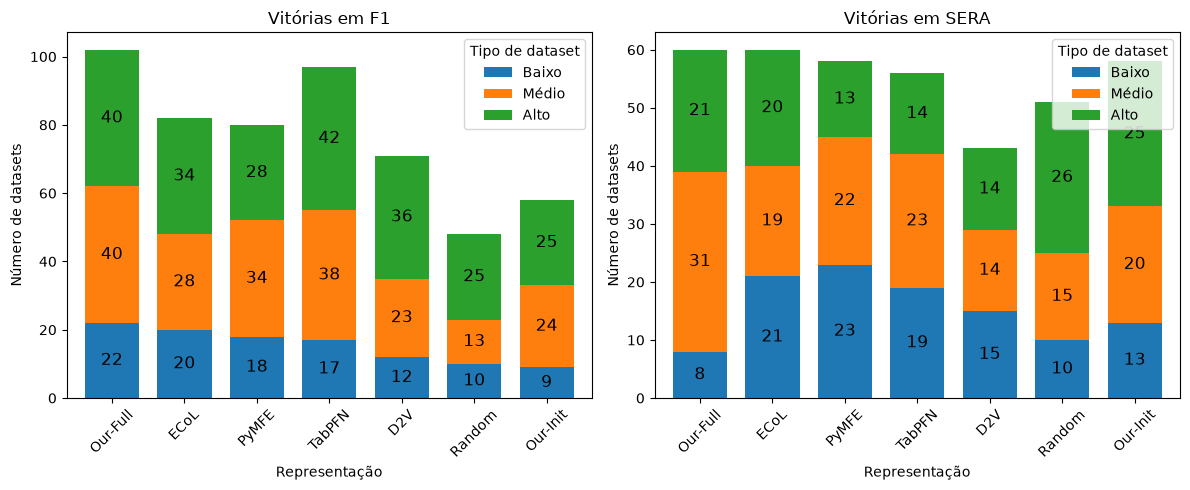

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
# Dados
f1 = pd.DataFrame({
    "Baixo": [22, 20, 18, 17, 12, 10, 9],
    "Médio": [40, 28, 34, 38, 23, 13, 24],
    "Alto":  [40, 34, 28, 42, 36, 25, 25],
}, index=["Our-Full", "ECoL", "PyMFE", "TabPFN", "D2V", "Random", "Our-Init"])

sera = pd.DataFrame({
    "Baixo": [8, 21, 23, 19, 15, 10, 13],
    "Médio": [31, 19, 22, 23, 14, 15, 20],
    "Alto":  [21, 20, 13, 14, 14, 26, 25],
}, index=["Our-Full", "ECoL", "PyMFE", "TabPFN", "D2V", "Random", "Our-Init"])


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in zip(
    axes,
    [f1, sera],
    ["F1", "SERA"]
):

    # Barra empilhada
    data.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.75
    )

    # Valores dentro de cada segmento
    for container in ax.containers:
        labels = [
            str(int(bar.get_height())) if bar.get_height() > 0 else ""
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            label_type="center",
            fontsize=12
        )

    ax.set_title(f"Vitórias em {title}")
    ax.set_xlabel("Representação")
    ax.set_ylabel("Número de datasets")
    ax.tick_params(axis="x", rotation=45)

    ax.legend(
        title="Tipo de dataset",
        loc="upper right"
    )

plt.tight_layout()
plt.show()

In [9]:
DESTAQUE = {"Our-Init", "Our-Full"}
cores_barras = ["crimson" if rep in DESTAQUE else "steelblue" for rep in REP_NAMES]

fig, axes = plt.subplots(len(NIVEIS), 2, figsize=(14, 5 * len(NIVEIS)))

for i, nivel in enumerate(NIVEIS):
    linha = (
        resumo_por_nivel_df[resumo_por_nivel_df["nivel"] == nivel]
        .set_index("representacao")
        .reindex(REP_NAMES)
    )
    n = linha["n_datasets"].iloc[0]

    linha["F1_mean"].plot(
        kind="bar", ax=axes[i, 0], color=cores_barras, title=f"F1 médio — {nivel} (n={n})"
    )
    axes[i, 0].axhline(linha["F1_mean_oraculo"].iloc[0], color="black", linestyle="--", linewidth=1, label="Oráculo")
    axes[i, 0].set_ylabel("F1")
    axes[i, 0].tick_params(axis="x", rotation=45)
    axes[i, 0].legend()

    linha["SERA_mean"].plot(
        kind="bar", ax=axes[i, 1], color=cores_barras, title=f"SERA médio — {nivel} (n={n})"
    )
    axes[i, 1].axhline(linha["SERA_mean_oraculo"].iloc[0], color="black", linestyle="--", linewidth=1, label="Oráculo")
    axes[i, 1].set_ylabel("SERA")
    axes[i, 1].tick_params(axis="x", rotation=45)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### Melhor representação por nível de desbalanceamento

In [ ]:
FOCO = ["Our-Init", "Our-Full"]
OUTRAS = [rep for rep in REP_NAMES if rep not in FOCO]

comparacao_foco = []
for nivel in NIVEIS:
    subset = base_per_instance[base_per_instance["nivel"] == nivel]
    linha = {"nivel": nivel, "n_datasets": len(subset)}

    for rep in FOCO:
        linha[f"F1_{rep}"] = subset[f"f1_{rep}"].mean()
        linha[f"SERA_{rep}"] = subset[f"sera_{rep}"].mean()

    linha["F1_melhor_outras"] = max(subset[f"f1_{rep}"].mean() for rep in OUTRAS)
    linha["rep_melhor_F1_outras"] = max(OUTRAS, key=lambda rep: subset[f"f1_{rep}"].mean())
    linha["SERA_melhor_outras"] = min(subset[f"sera_{rep}"].mean() for rep in OUTRAS)
    linha["rep_melhor_SERA_outras"] = min(OUTRAS, key=lambda rep: subset[f"sera_{rep}"].mean())

    comparacao_foco.append(linha)

comparacao_foco_df = pd.DataFrame(comparacao_foco)
comparacao_foco_df

,nivel,n_datasets,F1_Our-Init,SERA_Our-Init,F1_Our-Full,SERA_Our-Full,F1_melhor_outras,rep_melhor_F1_outras,SERA_melhor_outras,rep_melhor_SERA_outras
0,Baixo,49,0.332819,2.517739e+05,0.391321,2.928291e+05,0.412899,ECoL,2.804910e+05,Random
1,Médio,83,0.280013,9.977236e+10,0.312551,5.940990e+10,0.328932,PyMFE,6.765560e+10,TabPFN
2,Alto,83,0.125441,7.579455e+06,0.164375,2.726018e+06,0.159841,ECoL,3.098203e+06,D2V


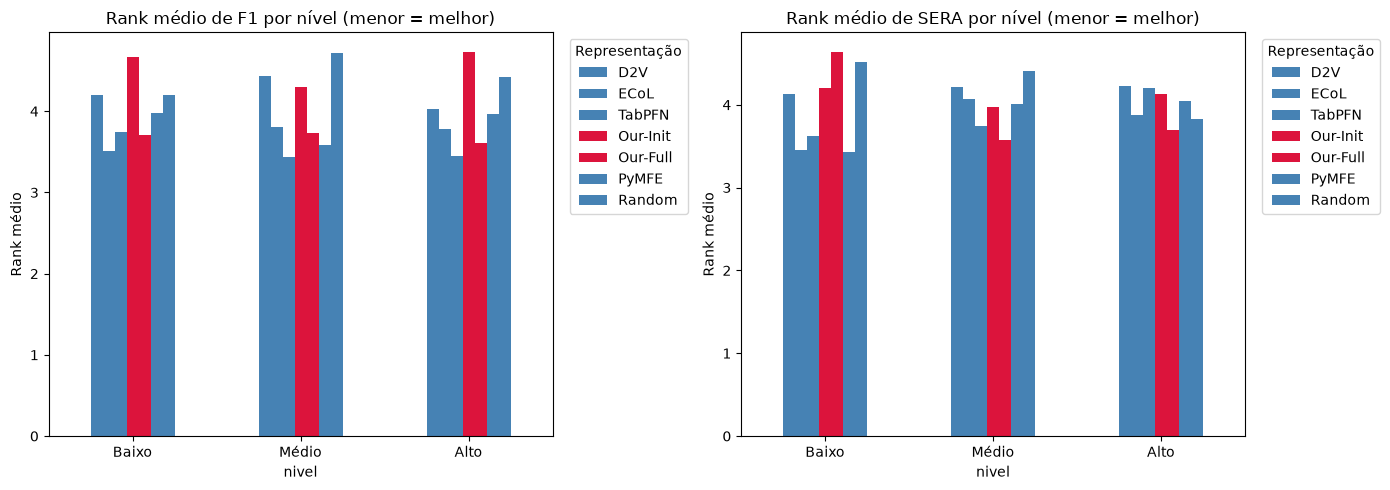

Rank médio de F1 (linhas = representação, colunas = nível; menor é melhor):


nivel,Baixo,Médio,Alto
representacao,,,
D2V,4.193878,4.433735,4.030120
ECoL,3.510204,3.801205,3.783133
TabPFN,3.744898,3.439759,3.451807
Our-Init,4.673469,4.301205,4.734940
Our-Full,3.704082,3.728916,3.608434
PyMFE,3.979592,3.578313,3.969880
Random,4.193878,4.716867,4.421687



Rank médio de SERA (linhas = representação, colunas = nível; menor é melhor):


nivel,Baixo,Médio,Alto
representacao,,,
D2V,4.132653,4.210843,4.228916
ECoL,3.448980,4.072289,3.873494
TabPFN,3.622449,3.746988,4.204819
Our-Init,4.204082,3.975904,4.132530
Our-Full,4.642857,3.572289,3.692771
PyMFE,3.428571,4.012048,4.042169
Random,4.520408,4.409639,3.825301


In [ ]:
def rank_medio_subset(df: pd.DataFrame, metric_prefix: str, ascending: bool) -> pd.Series:
    """Rank médio por representação num subconjunto (rank 1 = melhor no dataset)."""
    cols = [f"{metric_prefix}_{rep}" for rep in REP_NAMES]
    ranks = df[cols].rank(axis=1, method="average", ascending=ascending)
    ranks.columns = REP_NAMES
    return ranks.mean()


rank_por_nivel = []
for nivel in NIVEIS:
    subset = base_per_instance[base_per_instance["nivel"] == nivel]
    rank_f1 = rank_medio_subset(subset, "f1", ascending=False)   # maior F1 é melhor -> rank 1
    rank_sera = rank_medio_subset(subset, "sera", ascending=True)  # menor SERA é melhor -> rank 1
    for rep in REP_NAMES:
        rank_por_nivel.append({
            "nivel": nivel,
            "representacao": rep,
            "rank_medio_F1": rank_f1[rep],
            "rank_medio_SERA": rank_sera[rep],
        })

rank_por_nivel_df = pd.DataFrame(rank_por_nivel)

pivot_f1 = rank_por_nivel_df.pivot(index="representacao", columns="nivel", values="rank_medio_F1").reindex(REP_NAMES)[NIVEIS]
pivot_sera = rank_por_nivel_df.pivot(index="representacao", columns="nivel", values="rank_medio_SERA").reindex(REP_NAMES)[NIVEIS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_f1.T.plot(kind="bar", ax=axes[0], color=cores_barras, title="Rank médio de F1 por nível (menor = melhor)")
axes[0].set_ylabel("Rank médio")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Representação", bbox_to_anchor=(1.02, 1), loc="upper left")

pivot_sera.T.plot(kind="bar", ax=axes[1], color=cores_barras, title="Rank médio de SERA por nível (menor = melhor)")
axes[1].set_ylabel("Rank médio")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Representação", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

print("Rank médio de F1 (linhas = representação, colunas = nível; menor é melhor):")
display(pivot_f1)
print("\nRank médio de SERA (linhas = representação, colunas = nível; menor é melhor):")
display(pivot_sera)

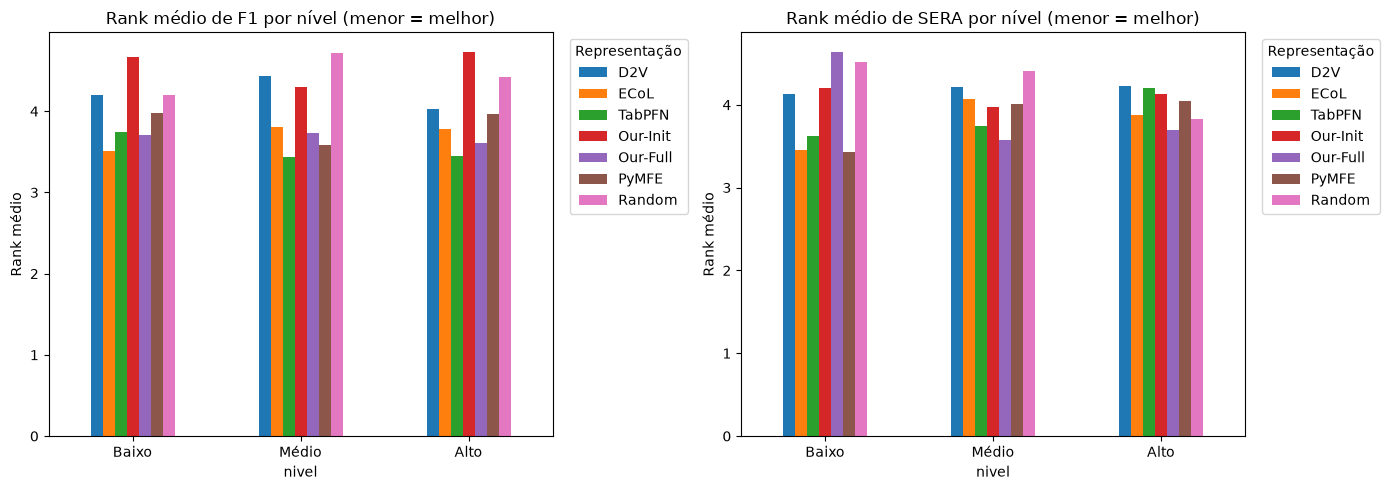

In [ ]:
paleta = plt.get_cmap("tab10").colors
cores_rank = {
    rep: paleta[i % len(paleta)]
    for i, rep in enumerate(REP_NAMES)
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_f1.T.plot(
    kind="bar",
    ax=axes[0],
    color=[cores_rank[rep] for rep in pivot_f1.index],
    title="Rank médio de F1 por nível (menor = melhor)",
)
axes[0].set_ylabel("Rank médio")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Representação", bbox_to_anchor=(1.02, 1), loc="upper left")

pivot_sera.T.plot(
    kind="bar",
    ax=axes[1],
    color=[cores_rank[rep] for rep in pivot_sera.index],
    title="Rank médio de SERA por nível (menor = melhor)",
)
axes[1].set_ylabel("Rank médio")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Representação", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
# Análise estatística e diagramas de diferença crítica por nível de desbalanceamento.
# Para cada nível são avaliadas separadamente as métricas F1 e SERA.

stats_por_nivel = []

for nivel in NIVEIS:
    subset_nivel = base_per_instance[
        base_per_instance["nivel"] == nivel
    ].copy()

    print(f"\n{'=' * 80}")
    print(f"NÍVEL DE DESBALANCEAMENTO: {nivel} (n={len(subset_nivel)})")
    print(f"{'=' * 80}")

    stats_nivel = critical_difference_analysis(
        subset_nivel,
        f"Predição do par — nível {nivel}",
    )

    stats_nivel.insert(0, "nivel", nivel)
    stats_por_nivel.append(stats_nivel)

stats_por_nivel_df = pd.concat(
    stats_por_nivel,
    ignore_index=True,
)

display(stats_por_nivel_df)

# Exporta os resultados estatísticos
stats_por_nivel_df.to_csv(
    "src/testes_estatisticos_por_nivel.csv",
    index=False,
)

print("Salvo: src/testes_estatisticos_por_nivel.csv")

NameError: name 'NIVEIS' is not defined

### Vitórias por nível de desbalanceamento
Aqui fiz umn gráfico mais bonito. Pois separei o gráfico "Par sugerido (model, strategy) — Nível Base (vitórias)" por nível de
desbalanceamento (`Baixo` / `Médio` / `Alto`, mesmos limiares de `%Rare` usados acima), mostrando
por representação quantas instâncias de cada nível ela vence (mais próxima do oráculo). Reaproveita
as contagens já calculadas em `vitorias_por_nivel`.

In [ ]:
cores_niveis = {"Baixo": "#a1d99b", "Médio": "#fdae6b", "Alto": "#de2d26"}

f1_vitorias_nivel = pd.DataFrame(
    {nivel: vitorias_por_nivel[nivel]["F1_vitorias"] for nivel in NIVEIS}
).reindex(REP_NAMES)[NIVEIS]

sera_vitorias_nivel = pd.DataFrame(
    {nivel: vitorias_por_nivel[nivel]["SERA_vitorias"] for nivel in NIVEIS}
).reindex(REP_NAMES)[NIVEIS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

f1_vitorias_nivel.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=[cores_niveis[nivel] for nivel in NIVEIS],
    title="F1 — vitórias por representação, empilhadas por nível de desbalanceamento",
)
axes[0].set_xlabel("Representação")
axes[0].set_ylabel("Número de vitórias")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Nível")

sera_vitorias_nivel.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=[cores_niveis[nivel] for nivel in NIVEIS],
    title="SERA — vitórias por representação, empilhadas por nível de desbalanceamento",
)
axes[1].set_xlabel("Representação")
axes[1].set_ylabel("Número de vitórias")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Nível")

for ax in axes:
    for container in ax.containers:
        labels = [f"{v:.0f}" if v > 0 else "" for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type="center", fontsize=9, color="black")

plt.tight_layout()
plt.show()

display(pd.concat(
    {"F1_vitorias": f1_vitorias_nivel, "SERA_vitorias": sera_vitorias_nivel},
    axis=1,
))

## Seleção de Meta-Features: Correlação, Agrupamento de Redundantes e Eliminação Reversa

As seções anteriores avaliam cada representação com **todas** as meta-features originais. Aqui investigamos se
parte dessas features é redundante (altamente correlacionada) e se reduzir a dimensionalidade — por
**agrupamento de colunas redundantes** seguido de **eliminação reversa** (RFECV, *Recursive Feature Elimination
with Cross-Validation*) — muda os resultados já obtidos (nível meta: `model`/`strategy`/par; nível base: F1/SERA
vs. Oráculo).

Pipeline aplicado a cada representação, separadamente:
1. **Matriz de correlação** (Spearman) entre as meta-features.
2. **Agrupamento de colunas redundantes**: clustering hierárquico sobre `1 - |correlação|`; mantém-se apenas 1
   representante (maior variância) por grupo com `|correlação| >= 0.9`.
3. **Eliminação reversa** (RFECV + RandomForest, validação cruzada estratificada, métrica F1 macro) sobre o
   conjunto já sem redundâncias, uma vez para prever `model` e outra para prever `strategy`.
4. Repetição do pipeline LOO-RF *model-first* com as features selecionadas, e comparação estatística (Wilcoxon
   pareado) dos resultados antes vs. depois, tanto no nível meta quanto no nível base.

In [ ]:
X_by_rep = {}
for rep, path in META_R.items():
    m = load_meta_r(path)
    m = m.set_index("ds_n").loc[instances].reset_index()
    X_by_rep[rep] = features_only(m).select_dtypes(include=[np.number])

corr_by_rep = {rep: X.corr(method="spearman") for rep, X in X_by_rep.items()}

for rep in REP_NAMES:
    print(f"{rep}: {X_by_rep[rep].shape[1]} meta-features")

In [ ]:
n_reps = len(REP_NAMES)
n_cols = 4
n_rows = int(np.ceil(n_reps / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

im = None
for ax, rep in zip(axes, REP_NAMES):
    corr = corr_by_rep[rep]
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(f"{rep} ({corr.shape[1]} features)")
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes[n_reps:]:
    ax.axis("off")

fig.colorbar(im, ax=axes.tolist(), shrink=0.6, label="Correlação de Spearman")
plt.suptitle("Matriz de correlação entre meta-features, por representação", y=1.02)
plt.show()

### Agrupamento de meta-features redundantes

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

CORR_THRESHOLD = 0.9  # |correlação de Spearman| >= 0.9 => redundante


def cluster_redundant_features(X: pd.DataFrame, corr_threshold: float = CORR_THRESHOLD):
    """Agrupa meta-features redundantes (alta correlação) via clustering hierárquico
    (distância = 1 - |correlação|) e mantém 1 representante por grupo (maior variância)."""
    corr = X.corr(method="spearman").abs().fillna(0.0)
    corr_arr = corr.to_numpy(copy=True)
    np.fill_diagonal(corr_arr, 1.0)
    dist = squareform(1 - corr_arr, checks=False)
    Z = linkage(dist, method="average")
    cluster_ids = fcluster(Z, t=1 - corr_threshold, criterion="distance")

    clusters = {}
    for col, cid in zip(X.columns, cluster_ids):
        clusters.setdefault(cid, []).append(col)

    representantes = [
        cols[0] if len(cols) == 1 else X[cols].var().idxmax()
        for cols in clusters.values()
    ]
    return X[representantes], clusters


X_reduced_by_rep = {}
clusters_by_rep = {}
agrupamento_rows = []

for rep in REP_NAMES:
    X_red, clusters = cluster_redundant_features(X_by_rep[rep])
    X_reduced_by_rep[rep] = X_red
    clusters_by_rep[rep] = clusters

    n_grupos_redundantes = sum(1 for cols in clusters.values() if len(cols) > 1)
    agrupamento_rows.append({
        "representacao": rep,
        "n_features_original": X_by_rep[rep].shape[1],
        "n_features_apos_agrupamento": X_red.shape[1],
        "n_grupos_redundantes": n_grupos_redundantes,
        "reducao_%": 100 * (1 - X_red.shape[1] / X_by_rep[rep].shape[1]),
    })

agrupamento_summary_df = pd.DataFrame(agrupamento_rows)
agrupamento_summary_df

In [ ]:
for rep in REP_NAMES:
    grupos = [cols for cols in clusters_by_rep[rep].values() if len(cols) > 1]
    if not grupos:
        print(f"[{rep}] nenhum grupo redundante (|correlação| >= {CORR_THRESHOLD}).")
        continue
    print(f"[{rep}] {len(grupos)} grupo(s) redundante(s):")
    for cols in grupos:
        representante = X_by_rep[rep][cols].var().idxmax()
        print(f"  - {cols} -> mantida: '{representante}'")

### Eliminação reversa (RFECV) sobre as meta-features

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

MIN_FEATURES = 5


def eliminacao_reversa(X: pd.DataFrame, y: pd.Series, seed: int = SEED) -> list[str]:
    """Eliminação reversa (RFECV): remove iterativamente as meta-features menos
    importantes (RandomForest) até maximizar o F1 macro em validação cruzada."""
    n_splits = min(5, y.value_counts().min())
    cv = StratifiedKFold(n_splits=max(2, n_splits), shuffle=True, random_state=seed)
    step = max(1, X.shape[1] // 20)  # remove ~5% por iteração (necessário p/ TabPFN, 512 features)

    selector = RFECV(
        estimator=RandomForestClassifier(n_estimators=100, random_state=seed),
        step=step,
        min_features_to_select=min(MIN_FEATURES, X.shape[1]),
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
    )
    selector.fit(X, y)
    return X.columns[selector.support_].tolist()

In [ ]:
selected_features = {}
selecao_rows = []

for rep in REP_NAMES:
    X_red = X_reduced_by_rep[rep]

    feats_model = eliminacao_reversa(X_red, model_true)
    feats_strategy = eliminacao_reversa(X_red, strategy_true)
    selected_features[rep] = {"model": feats_model, "strategy": feats_strategy}

    selecao_rows.append({
        "representacao": rep,
        "n_features_apos_agrupamento": X_red.shape[1],
        "n_features_selecionadas_model": len(feats_model),
        "n_features_selecionadas_strategy": len(feats_strategy),
    })
    print(
        f"[{rep}] após agrupamento: {X_red.shape[1]} features | "
        f"eliminação reversa -> model: {len(feats_model)} | strategy: {len(feats_strategy)}"
    )

selecao_summary_df = pd.DataFrame(selecao_rows)

pd.DataFrame([
    {"representacao": rep, "meta_task": task, "features_selecionadas": ", ".join(feats)}
    for rep, tasks in selected_features.items()
    for task, feats in tasks.items()
]).to_csv("src/meta_features_selecionadas.csv", index=False)
print("\nSalvo: src/meta_features_selecionadas.csv")

selecao_summary_df

### Recalculando o pipeline (nível meta e nível base) com as meta-features selecionadas

In [ ]:
def loo_predict_model_first_multi(
    X_model: pd.DataFrame,
    y_model: pd.Series,
    X_strategy: pd.DataFrame,
    y_strategy: pd.Series,
    seed: int = SEED,
) -> tuple[np.ndarray, np.ndarray]:
    """Versão de `loo_predict_model_first` com matrizes de features independentes
    para cada meta-task (usada com os subconjuntos selecionados por representação)."""
    model_pred = loo_predict(X_model, y_model, seed=seed)
    X_strategy_ext = pd.concat(
        [X_strategy.reset_index(drop=True), ohe_feature(model_pred, "model_pred")],
        axis=1,
    )
    strategy_pred = loo_predict(X_strategy_ext, y_strategy, seed=seed)
    return model_pred, strategy_pred

In [ ]:
preds_by_rep_fs = {}
meta_metrics_fs = []

for rep in REP_NAMES:
    X_red = X_reduced_by_rep[rep]
    feats_model = selected_features[rep]["model"]
    feats_strategy = selected_features[rep]["strategy"]

    model_pred, strategy_pred = loo_predict_model_first_multi(
        X_red[feats_model], model_true,
        X_red[feats_strategy], strategy_true,
    )
    pair_pred = make_pair(pd.Series(model_pred), pd.Series(strategy_pred)).to_numpy()
    preds_by_rep_fs[rep] = pair_pred

    meta_metrics_fs.append({
        "representacao": rep,
        "acc_model": accuracy_score(model_true, model_pred),
        "f1_macro_model": f1_score(model_true, model_pred, average="macro", zero_division=0),
        "acc_strategy": accuracy_score(strategy_true, strategy_pred),
        "f1_macro_strategy": f1_score(strategy_true, strategy_pred, average="macro", zero_division=0),
        "acc_par": accuracy_score(pair_true, pair_pred),
        "f1_macro_par": f1_score(pair_true, pair_pred, average="macro", zero_division=0),
    })
    last = meta_metrics_fs[-1]
    print(
        f"[{rep}] pós-seleção concluído — "
        f"model: acc={last['acc_model']:.3f} f1_macro={last['f1_macro_model']:.3f} | "
        f"strategy: acc={last['acc_strategy']:.3f} f1_macro={last['f1_macro_strategy']:.3f} | "
        f"par: acc={last['acc_par']:.3f} f1_macro={last['f1_macro_par']:.3f}"
    )

meta_metrics_fs_df = pd.DataFrame(meta_metrics_fs).set_index("representacao").reindex(REP_NAMES)

metric_cols = [
    "acc_model", "f1_macro_model", "acc_strategy", "f1_macro_strategy", "acc_par", "f1_macro_par",
]

comparacao_meta_fs_df = (
    meta_metrics_df.set_index("representacao")[metric_cols]
    .reindex(REP_NAMES)
    .add_suffix("_antes")
    .join(meta_metrics_fs_df[metric_cols].add_suffix("_depois"))
)
for metric in metric_cols:
    comparacao_meta_fs_df[f"{metric}_delta"] = (
        comparacao_meta_fs_df[f"{metric}_depois"] - comparacao_meta_fs_df[f"{metric}_antes"]
    )

comparacao_meta_fs_df

In [ ]:
base_rows_fs = []
for ds in base_per_instance["ds_n"]:
    i = idx_by_ds[ds]
    f1_row = f1_df.loc[ds]
    sera_row = sera_df.loc[ds]
    row = {"ds_n": ds}
    for rep in REP_NAMES:
        par_previsto = preds_by_rep_fs[rep][i]
        model_pred, strategy_pred = split_pair(par_previsto)
        col = base_col(model_pred, strategy_pred)
        row[f"par_previsto_{rep}"] = par_previsto
        row[f"f1_{rep}"] = f1_row[col]
        row[f"sera_{rep}"] = sera_row[col]
    base_rows_fs.append(row)

base_per_instance_fs = pd.DataFrame(base_rows_fs)
assert (base_per_instance_fs["ds_n"].to_numpy() == base_per_instance["ds_n"].to_numpy()).all()

comparacao_base_rows = []
for rep in REP_NAMES:
    comparacao_base_rows.append({
        "representacao": rep,
        "F1_mean_antes": base_per_instance[f"f1_{rep}"].mean(),
        "F1_mean_depois": base_per_instance_fs[f"f1_{rep}"].mean(),
        "SERA_mean_antes": base_per_instance[f"sera_{rep}"].mean(),
        "SERA_mean_depois": base_per_instance_fs[f"sera_{rep}"].mean(),
    })

comparacao_base_fs_df = pd.DataFrame(comparacao_base_rows)
comparacao_base_fs_df["F1_delta"] = comparacao_base_fs_df["F1_mean_depois"] - comparacao_base_fs_df["F1_mean_antes"]
comparacao_base_fs_df["SERA_delta"] = comparacao_base_fs_df["SERA_mean_depois"] - comparacao_base_fs_df["SERA_mean_antes"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(REP_NAMES))
width = 0.35

axes[0].bar(x - width / 2, comparacao_base_fs_df["F1_mean_antes"], width, label="Antes (todas as features)", color="steelblue")
axes[0].bar(x + width / 2, comparacao_base_fs_df["F1_mean_depois"], width, label="Depois (agrupamento + eliminação reversa)", color="crimson")
axes[0].set_xticks(x)
axes[0].set_xticklabels(REP_NAMES, rotation=45)
axes[0].set_ylabel("F1 médio (nível base)")
axes[0].set_title("F1 médio — antes vs. depois da seleção de features")
axes[0].legend()

axes[1].bar(x - width / 2, comparacao_base_fs_df["SERA_mean_antes"], width, label="Antes (todas as features)", color="steelblue")
axes[1].bar(x + width / 2, comparacao_base_fs_df["SERA_mean_depois"], width, label="Depois (agrupamento + eliminação reversa)", color="crimson")
axes[1].set_xticks(x)
axes[1].set_xticklabels(REP_NAMES, rotation=45)
axes[1].set_ylabel("SERA médio (nível base)")
axes[1].set_title("SERA médio — antes vs. depois da seleção de features")
axes[1].legend()

plt.tight_layout()
plt.show()

comparacao_base_fs_df

### Teste estatístico: antes vs. depois da seleção de features

In [ ]:
from scipy.stats import wilcoxon

testes_meta_fs = []
for metric in metric_cols:
    antes = meta_metrics_df.set_index("representacao")[metric].reindex(REP_NAMES)
    depois = meta_metrics_fs_df[metric]
    diff = depois - antes
    if np.allclose(diff, 0):
        stat, p = np.nan, 1.0
    else:
        stat, p = wilcoxon(antes, depois)
    testes_meta_fs.append({
        "nivel": "meta (n=7 representações)",
        "metrica": metric,
        "media_antes": antes.mean(),
        "media_depois": depois.mean(),
        "delta_medio": diff.mean(),
        "wilcoxon_statistic": stat,
        "wilcoxon_p_value": p,
        "significativo (alpha=0.05)": p < ALPHA,
    })

testes_meta_fs_df = pd.DataFrame(testes_meta_fs)
testes_meta_fs_df

In [ ]:
testes_base_fs = []
for rep in REP_NAMES:
    for metric_prefix in ["f1", "sera"]:
        antes = base_per_instance[f"{metric_prefix}_{rep}"].to_numpy()
        depois = base_per_instance_fs[f"{metric_prefix}_{rep}"].to_numpy()
        diff = depois - antes
        if np.allclose(diff, 0):
            stat, p = np.nan, 1.0
        else:
            stat, p = wilcoxon(antes, depois)
        testes_base_fs.append({
            "representacao": rep,
            "metrica": metric_prefix.upper(),
            "media_antes": antes.mean(),
            "media_depois": depois.mean(),
            "delta_medio": diff.mean(),
            "wilcoxon_statistic": stat,
            "wilcoxon_p_value": p,
            "significativo (alpha=0.05)": p < ALPHA,
        })

testes_base_fs_df = pd.DataFrame(testes_base_fs).sort_values(["metrica", "representacao"]).reset_index(drop=True)

comparacao_meta_fs_df.to_csv("src/comparacao_antes_depois_selecao_features_meta.csv")
comparacao_base_fs_df.to_csv("src/comparacao_antes_depois_selecao_features_base.csv", index=False)
testes_meta_fs_df.to_csv("src/testes_estatisticos_selecao_features_meta.csv", index=False)
testes_base_fs_df.to_csv("src/testes_estatisticos_selecao_features_base.csv", index=False)
print("Salvo: src/comparacao_antes_depois_selecao_features_meta.csv")
print("Salvo: src/comparacao_antes_depois_selecao_features_base.csv")
print("Salvo: src/testes_estatisticos_selecao_features_meta.csv")
print("Salvo: src/testes_estatisticos_selecao_features_base.csv")

testes_base_fs_df

In [ ]:
n_sig_meta = testes_meta_fs_df["significativo (alpha=0.05)"].sum()
n_sig_base = testes_base_fs_df["significativo (alpha=0.05)"].sum()

print(f"Testes de Wilcoxon (nível meta) significativos (alpha=0.05): {n_sig_meta}/{len(testes_meta_fs_df)}")
print(f"Testes de Wilcoxon (nível base) significativos (alpha=0.05): {n_sig_base}/{len(testes_base_fs_df)}")

if n_sig_meta == 0 and n_sig_base == 0:
    print(
        "\nConclusão: nenhum teste apontou diferença estatisticamente significativa. "
        "O agrupamento de features redundantes + eliminação reversa reduziu a "
        "dimensionalidade das meta-features sem alterar significativamente o "
        "desempenho (nem no nível meta, nem no nível base)."
    )
else:
    sig_rows = pd.concat([
        testes_meta_fs_df[testes_meta_fs_df["significativo (alpha=0.05)"]].assign(nivel="meta"),
        testes_base_fs_df[testes_base_fs_df["significativo (alpha=0.05)"]].assign(nivel="base"),
    ], ignore_index=True)
    print("\nConclusão: houve diferença estatisticamente significativa em pelo menos um caso:")
    display(sig_rows)